In [ ]:
# 1. Cài đặt và import thư viện
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [11]:
# Đọc ảnh từ Google Drive
# Đảm bảo ảnh đã được upload vào MyDrive/CV_2024_data/
img = cv.imread('Picture1.png')
img2 = cv.imread('Picture2.png')

In [3]:
# 2. Kiểm tra opencv đọc ảnh như thế nào và hiển thị chiều của ảnh
print("Kiểm tra thông tin ảnh:")
print(f"Shape của ảnh: {img.shape}")
print(f"Chiều cao (height): {img.shape[0]}")
print(f"Chiều rộng (width): {img.shape[1]}")
print(f"Số kênh màu (channels): {img.shape[2]}")
print(f"Kiểu dữ liệu: {img.dtype}")
print(f"Kích thước: {img.size}")

Kiểm tra thông tin ảnh:
Shape của ảnh: (650, 1280, 3)
Chiều cao (height): 650
Chiều rộng (width): 1280
Số kênh màu (channels): 3
Kiểu dữ liệu: uint8
Kích thước: 2496000


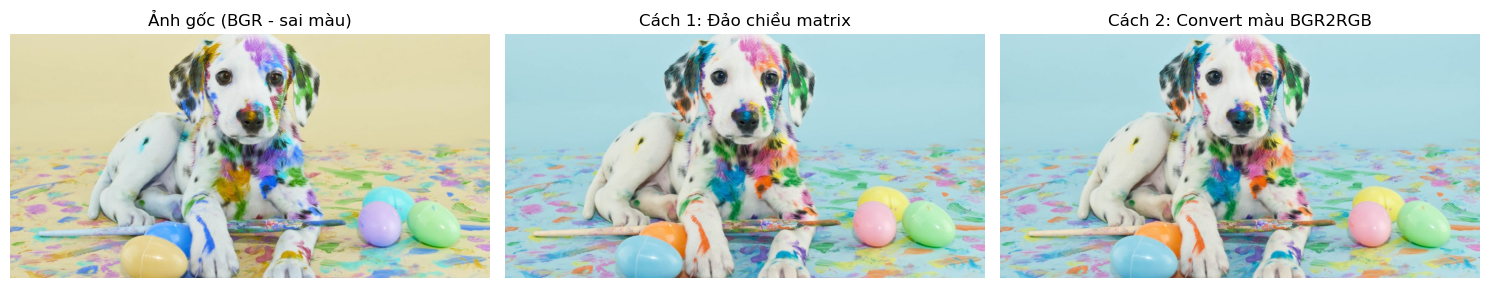


Nhận xét:
- OpenCV đọc ảnh theo định dạng BGR (Blue-Green-Red)
- Matplotlib hiển thị theo định dạng RGB (Red-Green-Blue)
- Do đó khi hiển thị trực tiếp bằng plt.imshow sẽ bị sai màu
- Cần chuyển đổi BGR sang RGB trước khi hiển thị


In [4]:
# 3. Hiển thị ảnh và nhận xét
plt.figure(figsize=(15, 5))

# Hiển thị ảnh gốc (sai màu - OpenCV đọc BGR)
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title('Ảnh gốc (BGR - sai màu)')
plt.axis('off')

# Cách 1: Đảo chiều matrix (BGR -> RGB)
img_rgb_method1 = img[:, :, ::-1]
plt.subplot(1, 3, 2)
plt.imshow(img_rgb_method1)
plt.title('Cách 1: Đảo chiều matrix')
plt.axis('off')

# Cách 2: Convert chế độ màu bằng cv.cvtColor
img_rgb_method2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.subplot(1, 3, 3)
plt.imshow(img_rgb_method2)
plt.title('Cách 2: Convert màu BGR2RGB')
plt.axis('off')

plt.tight_layout()
plt.show()

print("\nNhận xét:")
print("- OpenCV đọc ảnh theo định dạng BGR (Blue-Green-Red)")
print("- Matplotlib hiển thị theo định dạng RGB (Red-Green-Blue)")
print("- Do đó khi hiển thị trực tiếp bằng plt.imshow sẽ bị sai màu")
print("- Cần chuyển đổi BGR sang RGB trước khi hiển thị")


4. Phóng to ảnh:


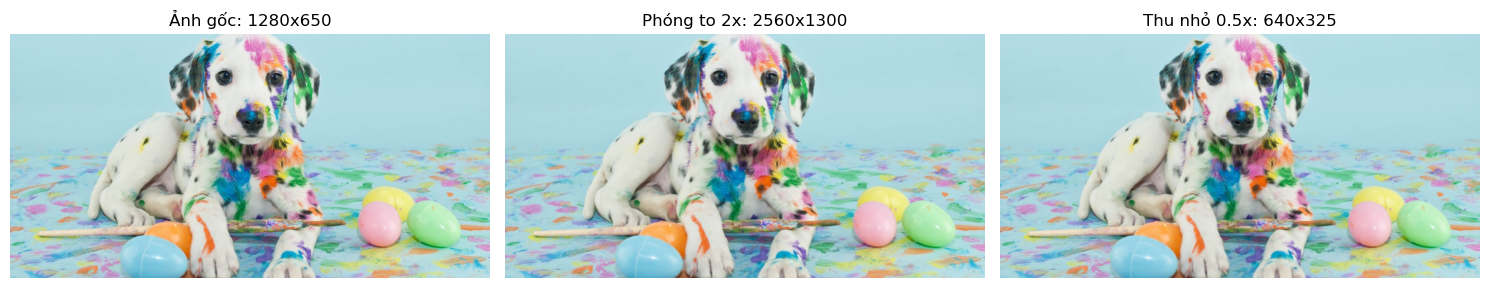

Kích thước ảnh gốc: (650, 1280, 3)
Kích thước ảnh phóng to 2x: (1300, 2560, 3)
Kích thước ảnh thu nhỏ 0.5x: (325, 640, 3)


In [8]:
# 4. Phóng to ảnh
print("\n4. Phóng to ảnh:")

# Chuyển sang RGB để hiển thị đúng
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

# Ảnh gốc
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f'Ảnh gốc: {img.shape[1]}x{img.shape[0]}')
plt.axis('off')

# Phóng to gấp 2 lần
scale_factor = 2
new_width = int(img.shape[1] * scale_factor)
new_height = int(img.shape[0] * scale_factor)
img_zoomed = cv.resize(img, (new_width, new_height), interpolation=cv.INTER_LINEAR)
img_zoomed_rgb = cv.cvtColor(img_zoomed, cv.COLOR_BGR2RGB)

plt.subplot(1, 3, 2)
plt.imshow(img_zoomed_rgb)
plt.title(f'Phóng to 2x: {img_zoomed.shape[1]}x{img_zoomed.shape[0]}')
plt.axis('off')

# Thu nhỏ 0.5 lần
img_shrink = cv.resize(img, (new_width//4, new_height//4), interpolation=cv.INTER_AREA)
img_shrink_rgb = cv.cvtColor(img_shrink, cv.COLOR_BGR2RGB)

plt.subplot(1, 3, 3)
plt.imshow(img_shrink_rgb)
plt.title(f'Thu nhỏ 0.5x: {img_shrink.shape[1]}x{img_shrink.shape[0]}')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Kích thước ảnh gốc: {img.shape}")
print(f"Kích thước ảnh phóng to 2x: {img_zoomed.shape}")
print(f"Kích thước ảnh thu nhỏ 0.5x: {img_shrink.shape}")


5. Crop ảnh:


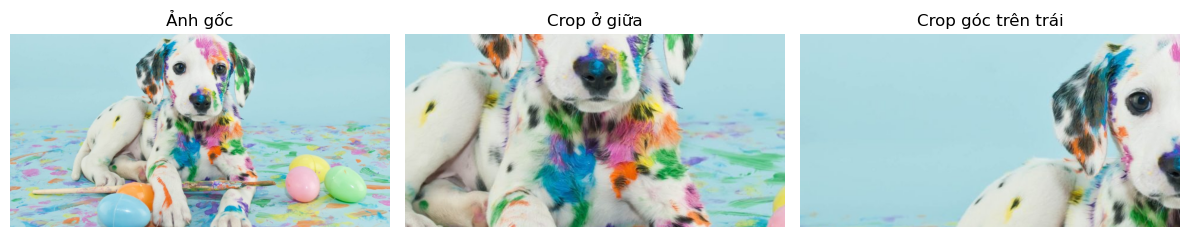

Kích thước ảnh gốc: (650, 1280, 3)
Kích thước ảnh crop giữa: (325, 640, 3)
Kích thước ảnh crop góc trên trái: (325, 640, 3)


In [9]:
# 5. Crop ảnh
print("\n5. Crop ảnh:")

plt.figure(figsize=(12, 4))

# Ảnh gốc
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Ảnh gốc')
plt.axis('off')

# Crop ở giữa ảnh
h, w = img.shape[:2]
start_row, start_col = h // 4, w // 4
end_row, end_col = 3 * h // 4, 3 * w // 4
img_cropped_center = img[start_row:end_row, start_col:end_col]
img_cropped_center_rgb = cv.cvtColor(img_cropped_center, cv.COLOR_BGR2RGB)

plt.subplot(1, 3, 2)
plt.imshow(img_cropped_center_rgb)
plt.title('Crop ở giữa')
plt.axis('off')

# Crop phần trên bên trái
img_cropped_topleft = img[0:h//2, 0:w//2]
img_cropped_topleft_rgb = cv.cvtColor(img_cropped_topleft, cv.COLOR_BGR2RGB)

plt.subplot(1, 3, 3)
plt.imshow(img_cropped_topleft_rgb)
plt.title('Crop góc trên trái')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Kích thước ảnh gốc: {img.shape}")
print(f"Kích thước ảnh crop giữa: {img_cropped_center.shape}")
print(f"Kích thước ảnh crop góc trên trái: {img_cropped_topleft.shape}")


6. Ghép dọc và ghép ngang 2 bức ảnh:


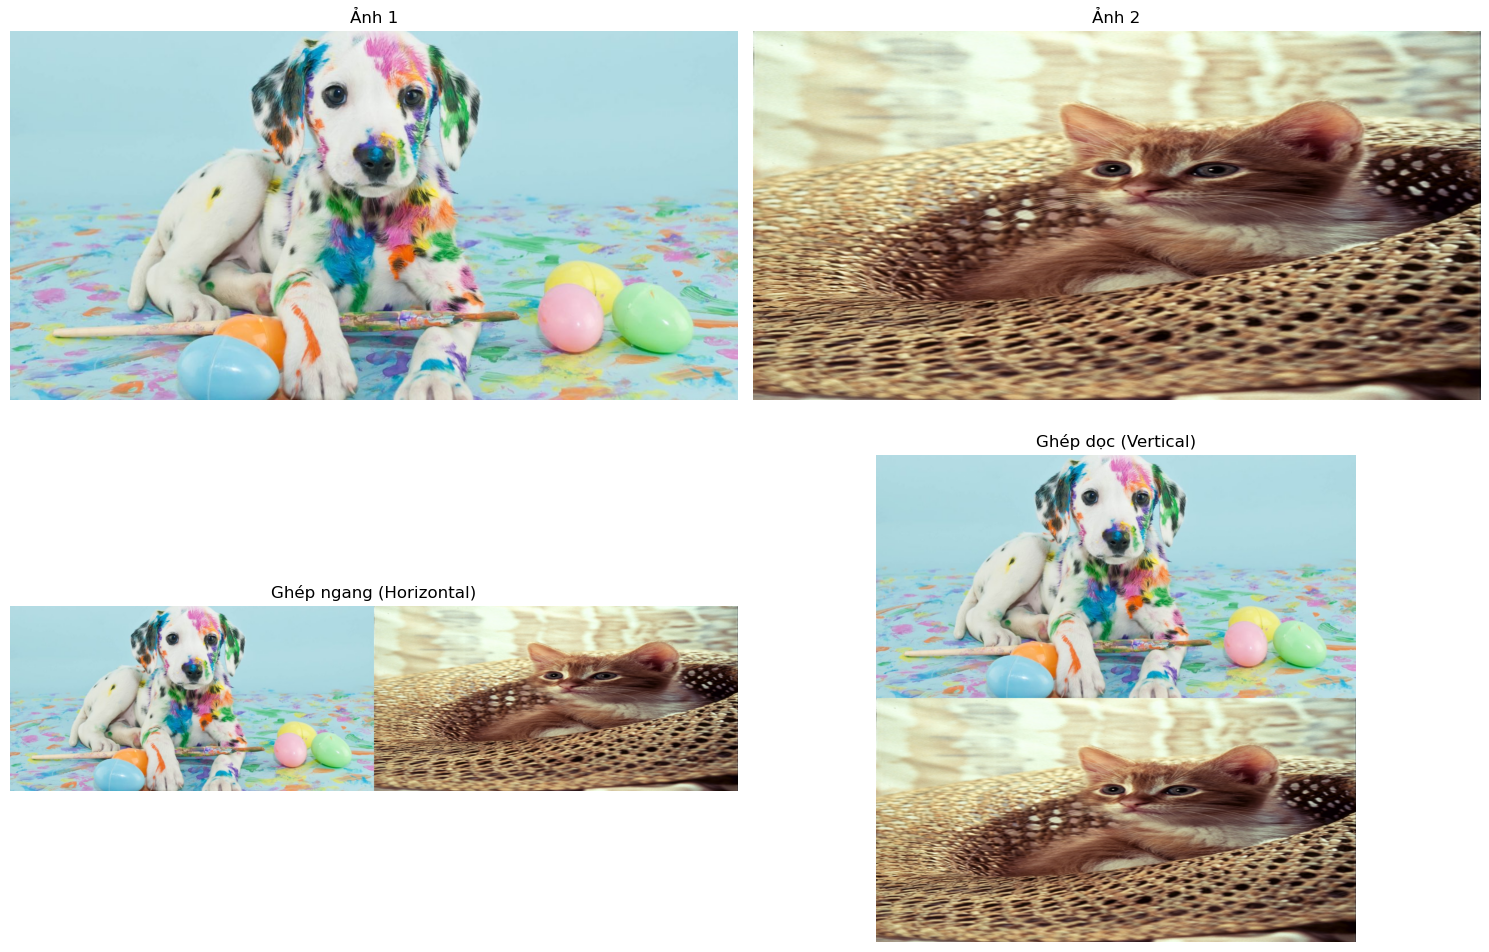

Kích thước ảnh ghép ngang: (650, 2560, 3)
Kích thước ảnh ghép dọc: (1300, 1280, 3)


In [ ]:
# 6. Ghép dọc và ghép ngang 2 bức ảnh
print("\n6. Ghép dọc và ghép ngang 2 bức ảnh:")

# Resize ảnh 2 cho cùng kích thước với ảnh 1 (để dễ ghép)
img2_resized = cv.resize(img2, (img.shape[1], img.shape[0]))

# Ghép ngang (horizontal concatenation)
img_hconcat = np.hstack((img, img2_resized))
img_hconcat_rgb = cv.cvtColor(img_hconcat, cv.COLOR_BGR2RGB)

# Ghép dọc (vertical concatenation)
img_vconcat = np.vstack((img, img2_resized))
img_vconcat_rgb = cv.cvtColor(img_vconcat, cv.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))

# Ảnh 1
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Ảnh 1')
plt.axis('off')

# Ảnh 2
plt.subplot(2, 2, 2)
img2_rgb = cv.cvtColor(img2_resized, cv.COLOR_BGR2RGB)
plt.imshow(img2_rgb)
plt.title('Ảnh 2')
plt.axis('off')

# Ghép ngang
plt.subplot(2, 2, 3)
plt.imshow(img_hconcat_rgb)
plt.title('Ghép ngang (Horizontal)')
plt.axis('off')

# Ghép dọc
plt.subplot(2, 2, 4)
plt.imshow(img_vconcat_rgb)
plt.title('Ghép dọc (Vertical)')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Kích thước ảnh ghép ngang: {img_hconcat.shape}")
print(f"Kích thước ảnh ghép dọc: {img_vconcat.shape}")